NOTEBOOK FÖR ATT TRÄNA OCH TESTA DATASET IRIS FÖR ATT KLASSIFICERA BLOMMOR 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

from minisom import MiniSom

from som_model import GeneralCLASSOM

In [7]:
def topographic_error(som, data):

    error_count = 0

    for x in data:

        # avstånd till alla neuroner
        weights = som.get_weights()
        dists = np.linalg.norm(weights - x, axis=2)

        # hitta BMU och second BMU
        bmu_idx = np.unravel_index(np.argmin(dists), dists.shape)

        dists[bmu_idx] = np.inf
        second_bmu = np.unravel_index(np.argmin(dists), dists.shape)

        # kontrollera om de är grannar
        if max(abs(bmu_idx[0]-second_bmu[0]),
               abs(bmu_idx[1]-second_bmu[1])) > 1:
            error_count += 1

    return error_count / len(data)

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

print("Dataset shape:", X.shape)
print("Classes:", class_names)

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (105, 4)
Test size: (45, 4)


In [108]:
som_model = GeneralCLASSOM(
    x=10,
    y=10,
    input_len=4,
    sigma=1.5,
    learning_rate=0.5
)

som_model.get_summary()

{'x': 10,
 'y': 10,
 'input_len': 4,
 'sigma': 1.5,
 'learning_rate': 0.5,
 'decay_function': 'asymptotic_decay',
 'neighborhood_function': 'gaussian',
 'topology': 'rectangular',
 'activation_distance': 'euclidean',
 'sigma_decay_function': 'asymptotic_decay',
 'random_seed': 42}

Kan välja mellan batch, standard och random 

Random kan användas för att Iris är ett litet dataset

In [109]:
som_model.train(
    X_train,
    iterations=1000,
    mode="standard",
    use_epochs = True 
)

 [    192 / 105000 ]   0% - 0:02:19 left 

 [ 105000 / 105000 ] 100% - 0:00:00 left 
 quantization error: 0.10280328027687959
Training completed (1000 iterations)


In [110]:
scaled_train = som_model.scaler.transform(X_train)

qe = som_model.som.quantization_error(scaled_train)

te = topographic_error(
    som_model.som,
    scaled_train
)

print("Quantization Error:", qe)
print("Topographic Error:", te)

Quantization Error: 0.10280328027687959
Topographic Error: 0.01904761904761905


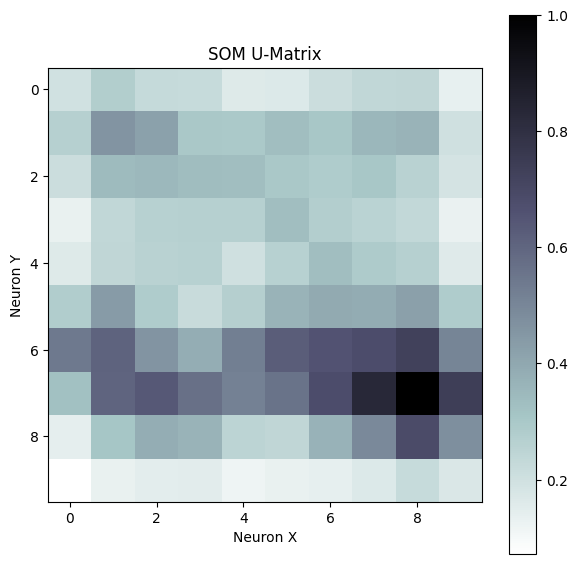

In [111]:
u_matrix = som_model.som.distance_map()

plt.figure(figsize=(7,7))

plt.imshow(u_matrix, cmap="bone_r")
plt.colorbar()

plt.title("SOM U-Matrix")

plt.xlabel("Neuron X")
plt.ylabel("Neuron Y")

plt.show()

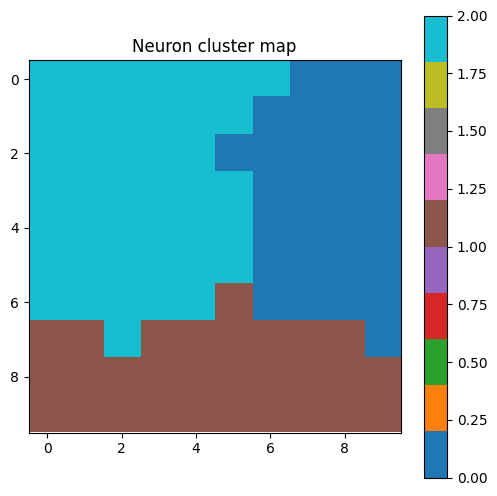

In [112]:
cluster_map = som_model.create_clusters(
    data=X_train,
    n_clusters=3,
    method="density"
)

plt.figure(figsize=(6,6))
plt.imshow(cluster_map, cmap="tab10")
plt.title("Neuron cluster map")
plt.colorbar()
plt.show()

In [113]:
cluster_to_class = {}

for cluster_id in np.unique(train_clusters):

    indices = np.where(train_clusters == cluster_id)

    majority_class = np.bincount(y_train[indices]).argmax()

    cluster_to_class[int(cluster_id)] = int(majority_class)

print("Cluster → Class mapping")

for c, cls in cluster_to_class.items():
    print(f"Cluster {c} → {class_names[cls]}")

Cluster → Class mapping
Cluster 0 → virginica
Cluster 1 → setosa
Cluster 2 → versicolor


In [114]:
test_clusters = som_model.predict_cluster(X_test)

y_pred = np.array([
    cluster_to_class[c] for c in test_clusters
])

In [115]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6888888888888889


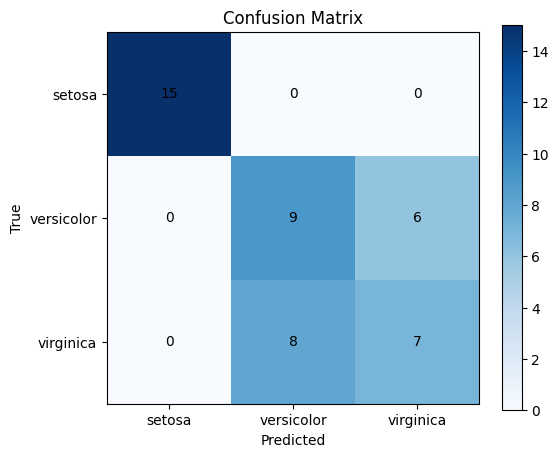

In [116]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")

plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [85]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.56      0.60      0.58        15
   virginica       0.57      0.53      0.55        15

    accuracy                           0.71        45
   macro avg       0.71      0.71      0.71        45
weighted avg       0.71      0.71      0.71        45

